In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from dotenv import load_dotenv
import os

load_dotenv()
sns.set_theme(style="whitegrid")

engine = create_engine(
    f"postgresql+psycopg2://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}"
    f"@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}"
)

df = pd.read_sql("SELECT * FROM raw_pcos_no_infertility", engine)

# Drop blank column
df = df.drop(columns=["unnamed_44"], errors="ignore")

print(f"Shape: {df.shape}")
print(f"\nPCOS distribution:\n{df['pcos_y_n'].value_counts()}")
df.head()

Shape: (541, 45)

PCOS distribution:
pcos_y_n
0    364
1    177
Name: count, dtype: int64


,sl_no,patient_file_no,pcos_y_n,age_yrs,weight_kg,height_cm,bmi,blood_group,pulse_rate_bpm,rr_breaths_min,...,fast_food_y_n,reg_exercise_y_n,bp_systolic_mmhg,bp_diastolic_mmhg,follicle_no_l,follicle_no_r,avg_f_size_l_mm,avg_f_size_r_mm,endometrium_mm,source
0,1,1,0,28,44.6,152.0,19.300000,15,78,22,...,1.0,0,110,80,3,3,18.0,18.0,8.5,kaggle_no_infertility
1,2,2,0,36,65.0,161.5,24.921163,15,74,20,...,0.0,0,120,70,3,5,15.0,14.0,3.7,kaggle_no_infertility
2,3,3,1,33,68.8,165.0,25.270891,11,72,18,...,1.0,0,120,80,13,15,18.0,20.0,10.0,kaggle_no_infertility
3,4,4,0,37,65.0,148.0,29.674945,13,72,20,...,0.0,0,120,70,2,2,15.0,14.0,7.5,kaggle_no_infertility
4,5,5,0,25,52.0,161.0,20.060954,11,72,18,...,0.0,0,120,80,3,4,16.0,14.0,7.0,kaggle_no_infertility


In [3]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Missing values:\n", missing)

Missing values:
 marraige_status_yrs    1
fast_food_y_n          1
dtype: int64


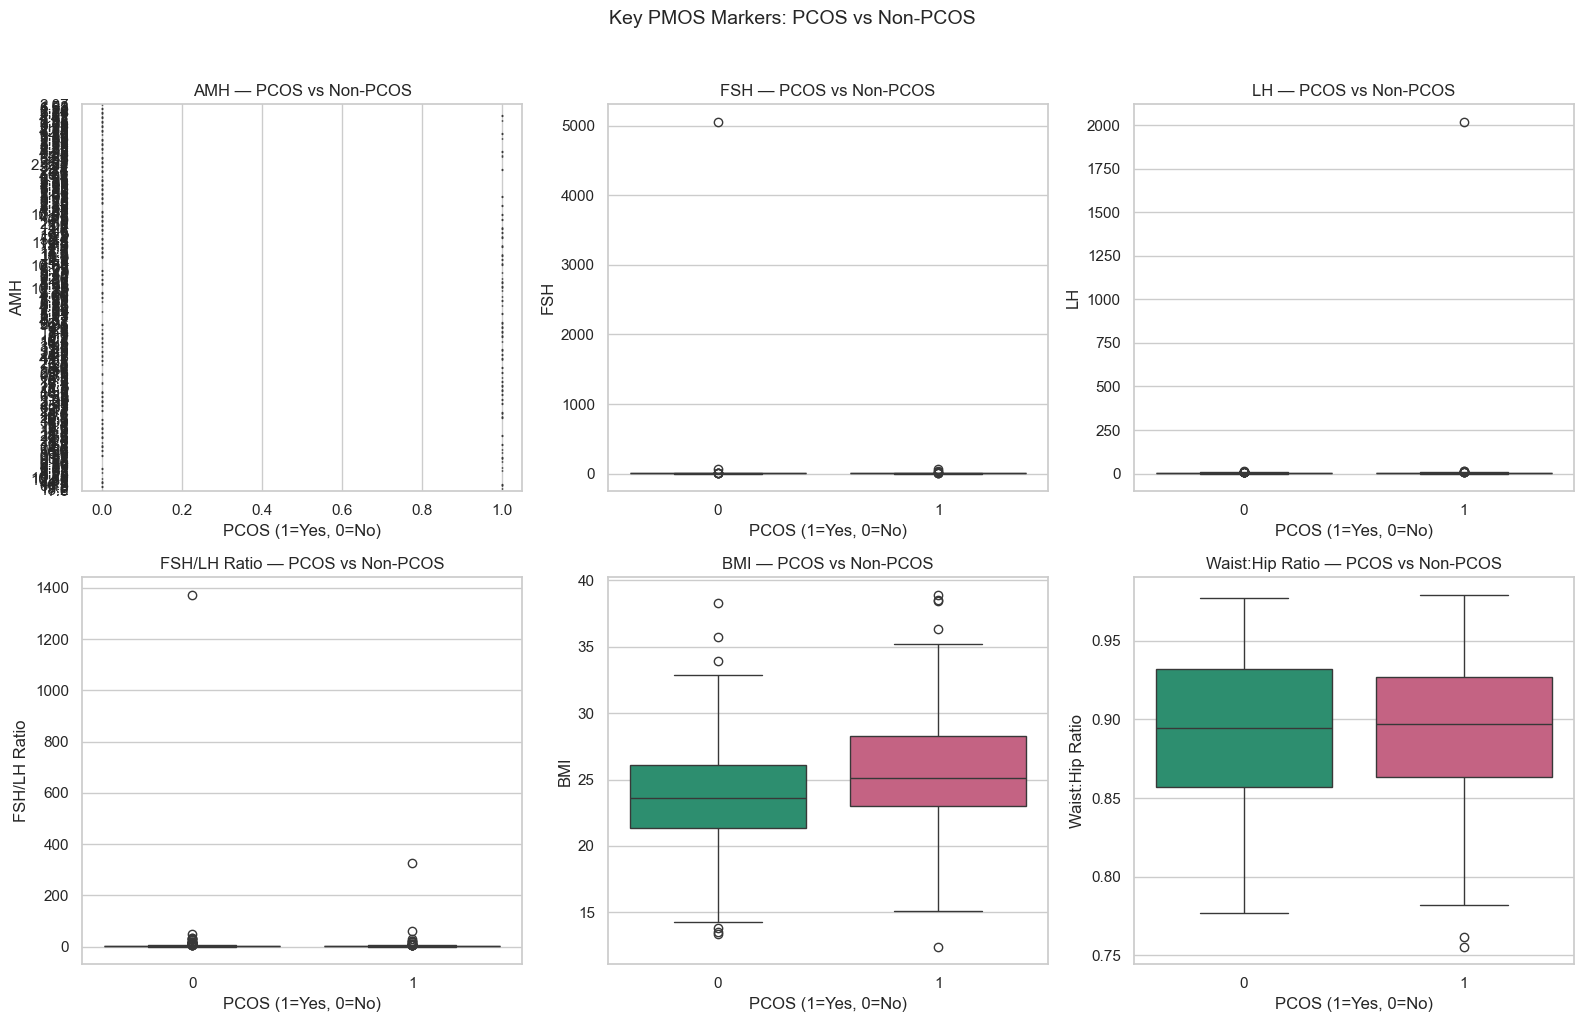

In [4]:
markers = ["amh_ng_ml", "fsh_miu_ml", "lh_miu_ml", "fsh_lh", "bmi", "waist_hip_ratio"]
labels  = ["AMH", "FSH", "LH", "FSH/LH Ratio", "BMI", "Waist:Hip Ratio"]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, (col, label) in enumerate(zip(markers, labels)):
    sns.boxplot(data=df, x="pcos_y_n", y=col,
                palette={0: "#1D9E75", 1: "#D4537E"},
                ax=axes[i], hue="pcos_y_n", legend=False)
    axes[i].set_title(f"{label} — PCOS vs Non-PCOS")
    axes[i].set_xlabel("PCOS (1=Yes, 0=No)")
    axes[i].set_ylabel(label)

plt.suptitle("Key PMOS Markers: PCOS vs Non-PCOS", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

Non-numeric values replaced with NaN
amh_ng_ml          1
fsh_miu_ml         0
lh_miu_ml          0
fsh_lh             0
tsh_miu_l          0
prl_ng_ml          0
vit_d3_ng_ml       0
bmi                0
waist_hip_ratio    0
pcos_y_n           0
dtype: int64


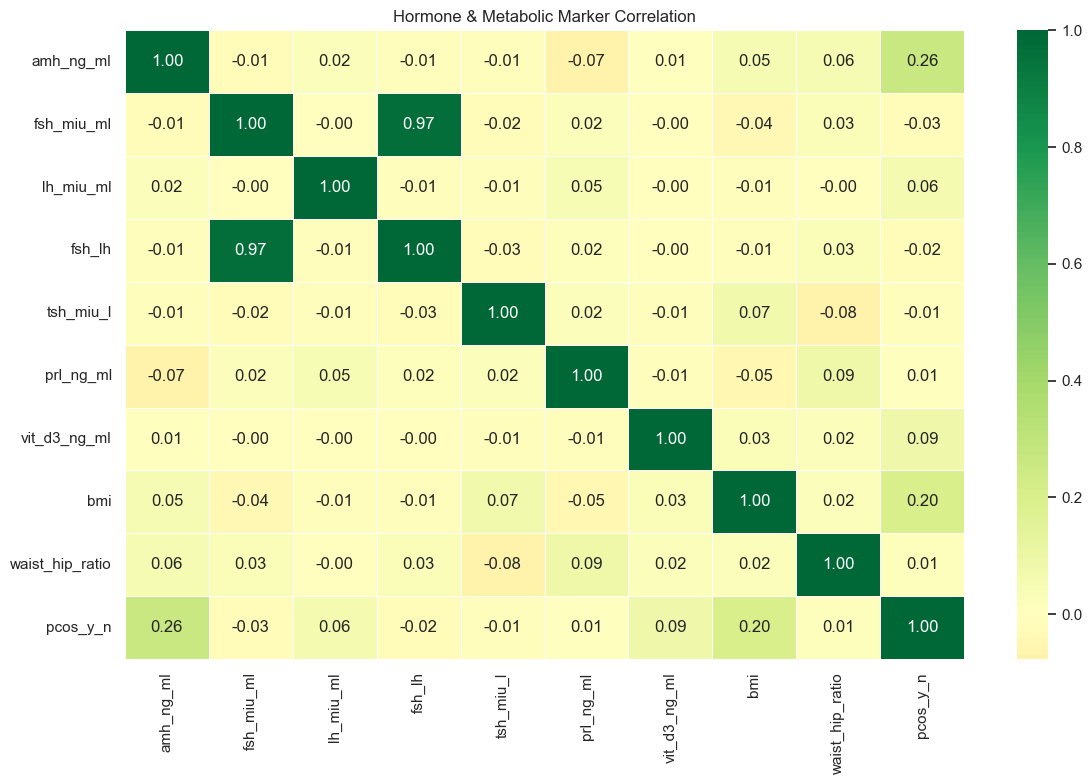

In [8]:
# Clean — force all hormone columns to numeric
for col in hormone_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print("Non-numeric values replaced with NaN")
print(df[hormone_cols].isnull().sum())
hormone_cols = ["amh_ng_ml", "fsh_miu_ml", "lh_miu_ml", "fsh_lh",
                "tsh_miu_l", "prl_ng_ml", "vit_d3_ng_ml", "bmi",
                "waist_hip_ratio", "pcos_y_n"]

corr = df[hormone_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdYlGn",
            center=0, linewidths=0.5)
plt.title("Hormone & Metabolic Marker Correlation")
plt.tight_layout()
plt.show()

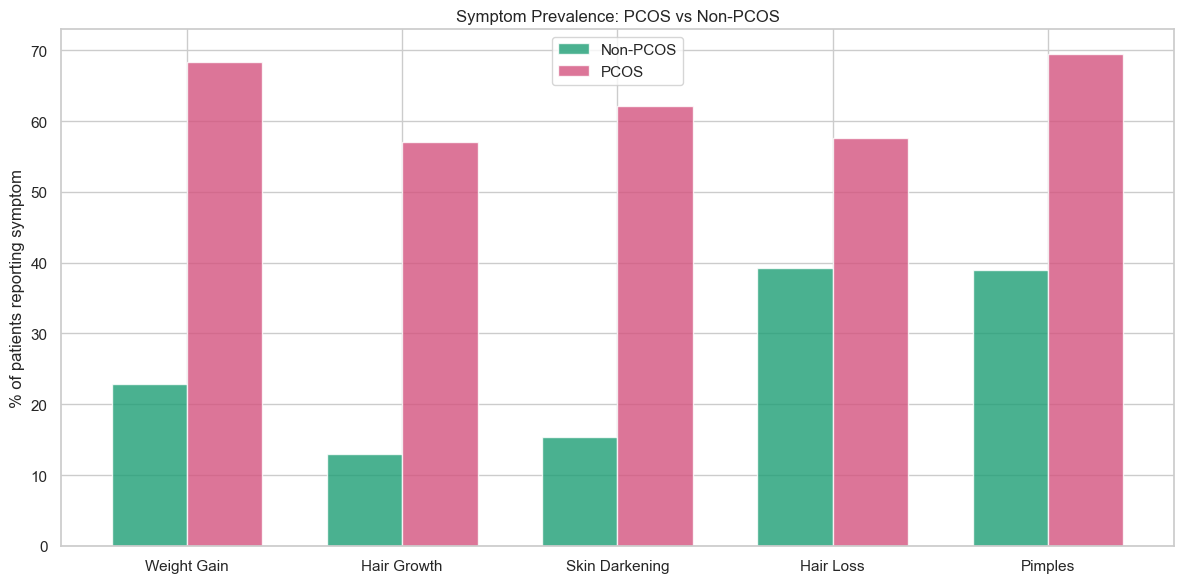

In [9]:
symptom_cols = ["weight_gain_y_n", "hair_growth_y_n", "skin_darkening_y_n",
                "hair_loss_y_n", "pimples_y_n"]
symptom_labels = ["Weight Gain", "Hair Growth", "Skin Darkening", "Hair Loss", "Pimples"]

pcos_symptoms     = df[df["pcos_y_n"]==1][symptom_cols].mean() * 100
non_pcos_symptoms = df[df["pcos_y_n"]==0][symptom_cols].mean() * 100

x = np.arange(len(symptom_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - width/2, non_pcos_symptoms, width, label="Non-PCOS", color="#1D9E75", alpha=0.8)
ax.bar(x + width/2, pcos_symptoms,     width, label="PCOS",     color="#D4537E", alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(symptom_labels)
ax.set_ylabel("% of patients reporting symptom")
ax.set_title("Symptom Prevalence: PCOS vs Non-PCOS")
ax.legend()
plt.tight_layout()
plt.show()